In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

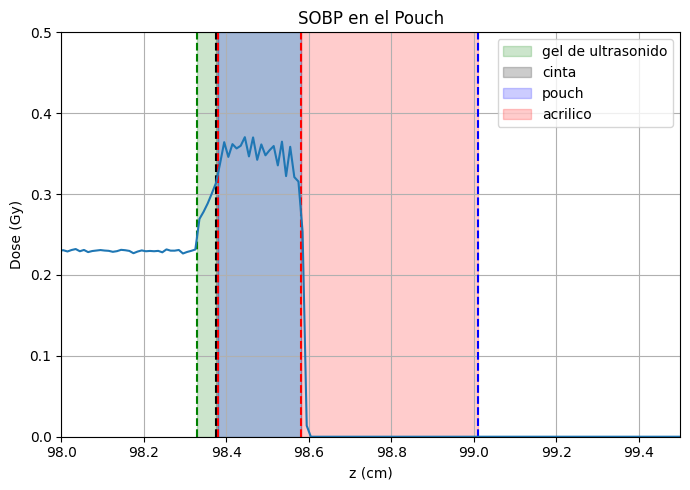

In [7]:
#DOSIS VS Z
archivo = "../out/bragg_pouch_zsinat.out"

tiemporad = 1

z = []
dose = []


with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()


        if len(parts) != 4:
            continue


        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue


        z.append((z1 + z2) / 2)
        dose.append(d)


plt.figure(figsize=(7,5))

plt.axvline(x=98.375, color='k', linestyle='--') # max cinta
plt.axvline(x=98.33, color='g', linestyle='--') # max gel de ultrasonido
plt.axvline(x=98.38,color='r', linestyle='--')    # max pouch, min cinta
plt.axvline(x=98.58, color = 'r', linestyle='--') # min pouch , max trampolin , min gel
plt.axvline(x=99.01, color = 'b', linestyle='--') # min trampolin
#plt.axvline(x = 60.23, color = 'g', linestyle='--'  )

plt.axvspan(98.33, 98.58, color='g', alpha=0.2, label='gel de ultrasonido')
plt.axvspan(98.375, 98.38, color='k', alpha=0.2, label='cinta')
plt.axvspan(98.38, 98.58, color='b', alpha=0.2, label='pouch')
plt.axvspan(98.58, 99.01, color='r', alpha=0.2, label='acrilico')
#plt.axvspan(60.23, 60.58, color='g', alpha=0.2, label='gel de ultrasonido')

plt.legend()
plt.ylim(0, 0.5)
plt.xlim(98, 99.5)
plt.plot(z, np.array(dose)*tiemporad)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)") # gray por particula simulada (u)
plt.title("SOBP en el Pouch")
plt.grid(True)
plt.tight_layout()
plt.show()